In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

/home/njs/miniconda3/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [ ]:
model = CmdStanModel(stan_file='trape1.stan')
fit = model.sample(data='trape_individuals.json', show_console=False, show_progress=True, chains=4, parallel_chains=4)

print(fit.summary())

draws = fit.draws_pd()
draws.to_csv('trape1_draws.csv')
with open('trape1_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

08:27:22 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:27:56 - cmdstanpy - INFO - CmdStan done processing.
08:27:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to column 90)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape13.stan', line 58, column 8 to col


                     Mean      MCSE     StdDev           5%          50%  \
lp__          6815.530000  0.529883  19.102600  6783.270000  6815.890000   
tau_elp[1]       0.777559  0.005667   0.388823     0.237748     0.724688   
tau_elp[2]       1.174980  0.013401   0.679560     0.111521     1.178390   
tau_elp[3]       1.142150  0.006808   0.491572     0.436223     1.090320   
tau_elp[4]       1.543360  0.008371   0.564899     0.671781     1.508360   
...                   ...       ...        ...          ...          ...   
log_lik[634]    -2.125020  0.010589   0.658037    -3.463480    -1.913220   
log_lik[635]    -1.103210  0.003210   0.142579    -1.395130    -1.047840   
log_lik[636]    -0.524493  0.004664   0.332918    -1.184990    -0.452629   
log_lik[637]    -0.214387  0.003324   0.211203    -0.627829    -0.147825   
log_lik[638]    -0.042307  0.001357   0.076881    -0.168902    -0.016587   

                      95%    N_Eff   N_Eff/s     R_hat  
lp__          6846.930000  12

In [18]:
with open('trape1_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [19]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [20]:
i = 1 # index of individual to extract: 1 to 111
vars = ['lambda', 'rho_elp', 'tau_elp', 'delta_clinical', 'rho_clinical']
y = z.posterior.isel(lambda_dim_0=i, rho_elp_dim_0=i, tau_elp_dim_0=i, delta_clinical_dim_0=i, rho_clinical_dim_0=i)

Rhat values good

In [21]:
print(az.rhat(y, var_names=vars))

<xarray.Dataset> Size: 80B
Dimensions:               ()
Coordinates:
    tau_elp_dim_0         int64 8B 1
    rho_elp_dim_0         int64 8B 1
    rho_clinical_dim_0    int64 8B 1
    lambda_dim_0          int64 8B 1
    delta_clinical_dim_0  int64 8B 1
Data variables:
    lambda                float64 8B 1.002
    rho_elp               float64 8B 1.0
    tau_elp               float64 8B 1.001
    delta_clinical        float64 8B 1.0
    rho_clinical          float64 8B 1.0


Effective samples sizes good

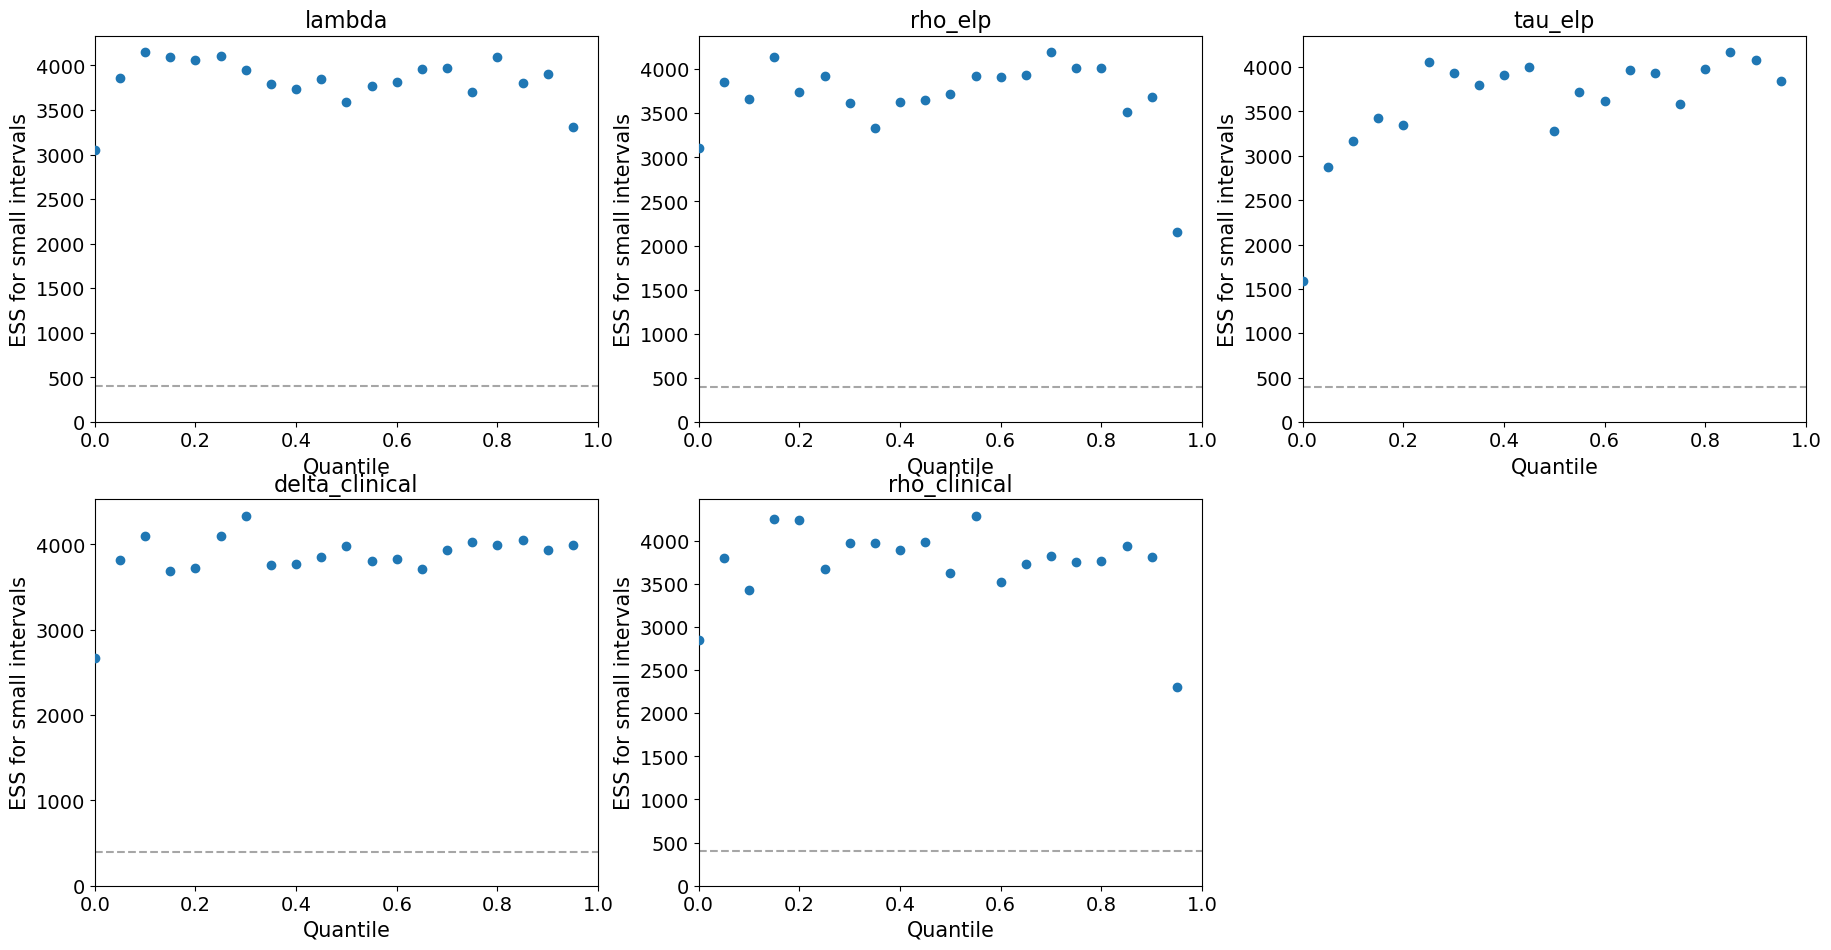

In [22]:
az.plot_ess(y, var_names=vars);

No major autocorrelation

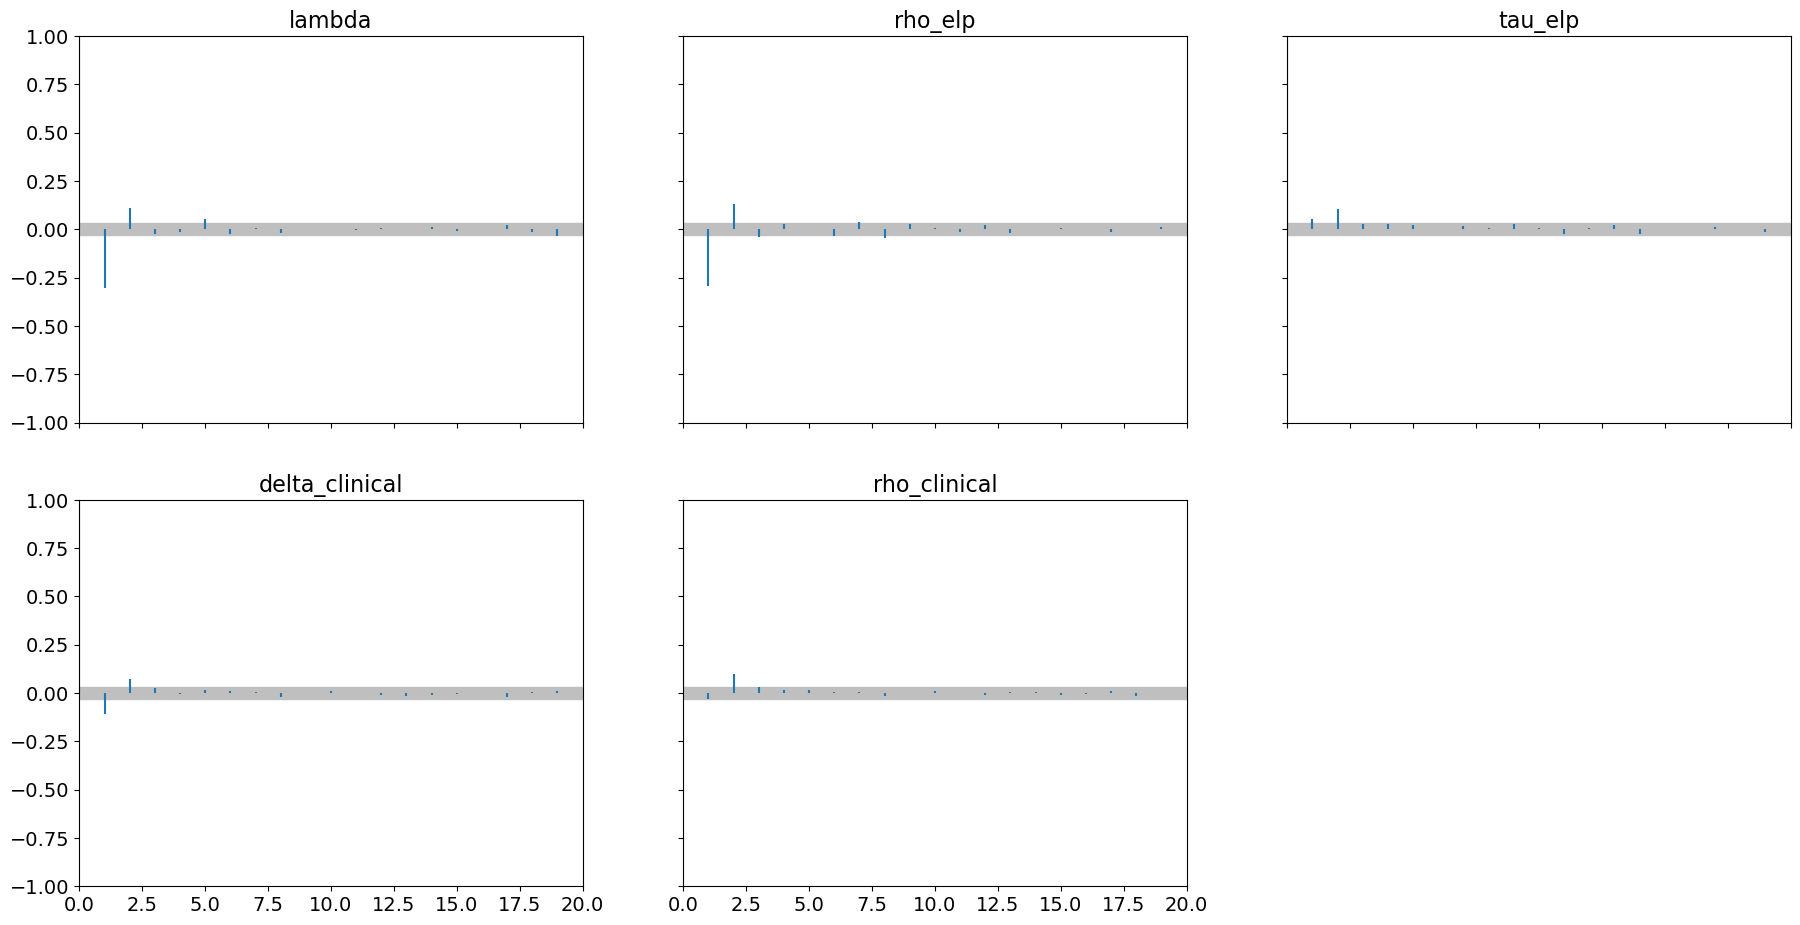

In [23]:
az.plot_autocorr(y, var_names=vars, combined=True, max_lag=20,);

Chains look goo. No divergences indicated.

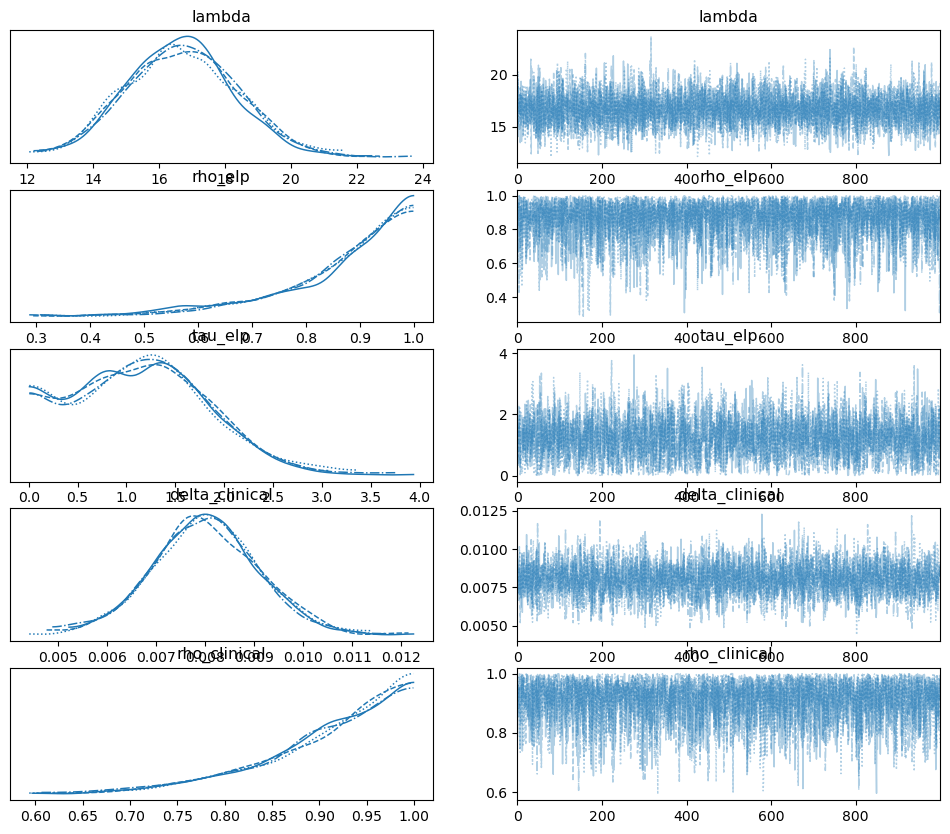

In [24]:
az.plot_trace(y, var_names=vars);

Pair plot reveals identifiability issue between rho_clinical and delta_clinical

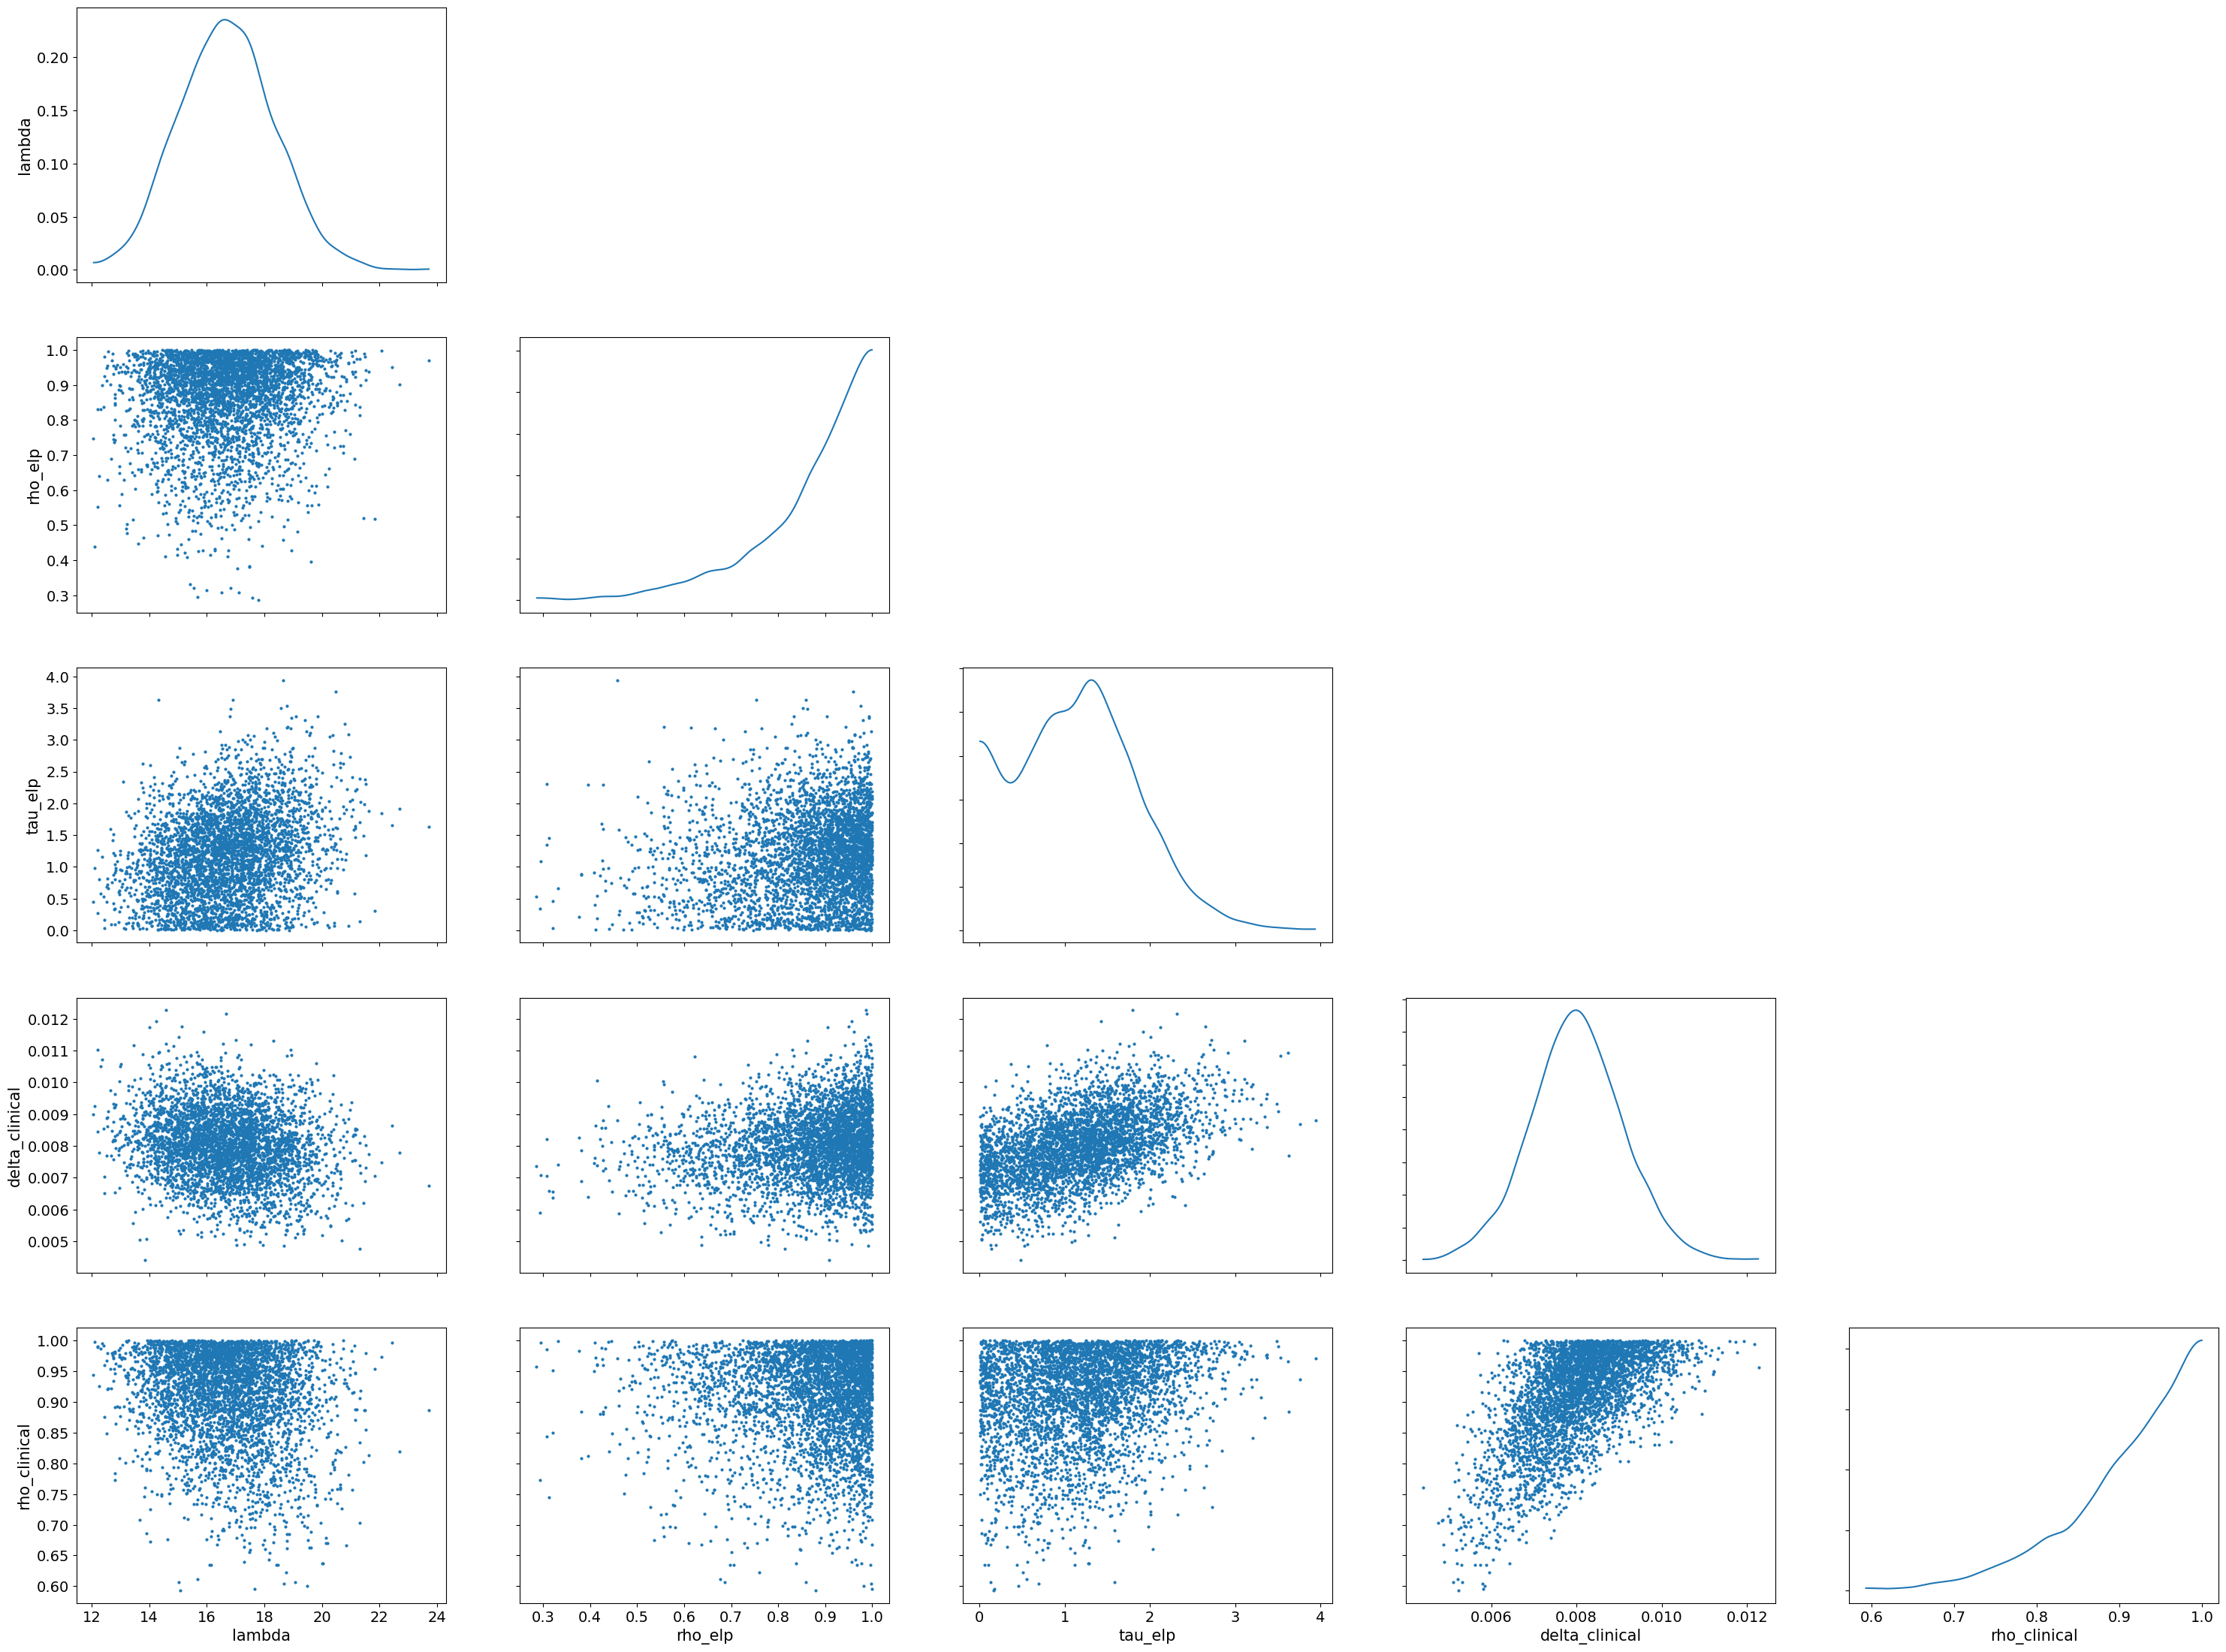

In [28]:
az.plot_pair(y, var_names=vars, marginals=True);